In [348]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

In [349]:
vehicles = pd.read_csv("US_Accidents_March23_sampled_500k.csv", index_col=0)
df = vehicles.copy()

In [350]:
df

,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
ID,,,,,,,,,,,,,,,,,,,,,
A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,Accident on LA-19 Baker-Zachary Hwy at Lower Z...,...,False,False,False,False,True,False,Day,Day,Day,Day
A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,Incident on FOREST RIDGE DR near PEPPERIDGE PL...,...,False,False,False,False,False,False,Night,Night,Night,Night
A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,Accident on W Central Ave from Floradale Ave t...,...,False,False,False,False,True,False,Day,Day,Day,Day
A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,Incident on I-90 EB near REST AREA Drive with ...,...,False,False,False,False,False,False,Day,Day,Day,Day
A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,RP ADV THEY LOCATED SUSP VEH OF 20002 - 726 CR...,...,False,False,False,False,False,False,Night,Night,Night,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A-6077227,Source1,2,2021-12-15 07:30:00,2021-12-15 07:50:30,45.522510,-123.084104,45.520225,-123.084211,0.158,Stationary traffic on OR-47 from NW Martin Rd ...,...,False,False,False,False,False,False,Night,Day,Day,Day
A-6323243,Source1,2,2021-12-19 16:25:00,2021-12-19 17:40:37,26.702570,-80.111169,26.703141,-80.111133,0.040,Incident on MILITARY TRL near WESTGATE AVE Dri...,...,False,False,False,False,False,False,Day,Day,Day,Day
A-3789256,Source1,2,2022-04-13 19:28:29,2022-04-13 21:33:44,34.561862,-112.259620,34.566822,-112.267150,0.549,Crash on the right shoulder on E SR-69 Northbo...,...,False,False,False,False,True,False,Night,Night,Day,Day


In [351]:
df.isnull().sum()

Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  220377
End_Lng                  220377
Distance(mi)                  0
Description                   1
Street                      691
City                         19
County                        0
State                         0
Zipcode                     116
Country                       0
Timezone                    507
Airport_Code               1446
Weather_Timestamp          7674
Temperature(F)            10466
Wind_Chill(F)            129017
Humidity(%)               11130
Pressure(in)               8928
Visibility(mi)            11291
Wind_Direction            11197
Wind_Speed(mph)           36987
Precipitation(in)        142616
Weather_Condition         11101
Amenity                       0
Bump                          0
Crossing                      0
Give_Way

In [352]:
# So to start with lets identify the obvious columns that we do not want to work with since it is irrelevant for our purposes of classifying the severity of accidents
df = df.drop(columns=[
    'Source', # Where the data is sourced from
    # We dont want any of the coordinates we have the country, county and street, state, they are derived from the coordinates
    'Start_Lat', 
    'Start_Lng', 
    'End_Lat', 
    'End_Lng', 
    'Country', # 100% of the values in Country is the US and we know that this dataset is from the US so we can take it out 
    'Airport_Code', # No need for this one
    'Timezone', # We do not need a timezone such as US/Cental or US/Pacific since we want to know what time of day is relevant at each place
    'Description', # We dont need the human language description it adds no value since it just states that an accident happened in a specific county
    'Wind_Direction' # This feature does not really add much since if wind_speed is 0 it says CALM but we get that from the wind speed and if its >0 it only shows direction, this would not have an effect on cars
])

In [353]:
# Location information could be important especially when gaining insights into accidents but for our model these add redundancy
# Since Street is inside of a City which is inside of a State, its the same information but some are broader and some are more specific
# We are looking at Street, City, County, State, Zipcode
# Ideally we would like to identify 1 that is most descriptive and drop the rest
# Especially if we want to compare the accident data to population it could be best to keep only the State
print(df['Street'].value_counts().describe()) # 88273 unique streets and most streets only appear a few times this does not generalize well and probably introduces noise
print(df['City'].value_counts().describe()) # 9489 unique cities, most appear a few times so could generalize well and is fairly balanced 
print(df['County'].value_counts().describe()) # This has much fewer unique values as expected but is not as precise as city
print(df['State'].value_counts().describe()) # 49 states in this dataset so we are missing one, this is not as precise, could work well for analysis but to start with we want to try City
print(df['Zipcode'].value_counts().describe()) # 127805 zip codes is too many to generalize well

# In conclusion, to start with we want to see if we can use city since it has enough unique values to be somewhat precise and capture some similarities but not too few to be too sparse, we might switch to State later
df = df.drop(columns=[
    'Street',
    'County', 
    'State', 
    'Zipcode', 
])

count    88272.000000
mean         5.656482
std         49.408383
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       4973.000000
Name: count, dtype: float64
count     9488.000000
mean        52.696142
std        321.112628
min          1.000000
25%          2.000000
50%          6.000000
75%         25.000000
max      12141.000000
Name: count, dtype: float64
count     1606.000000
mean       311.332503
std       1337.224065
min          1.000000
25%          4.000000
50%         22.000000
75%        125.000000
max      34247.000000
Name: count, dtype: float64
count        49.000000
mean      10204.081633
std       18368.889024
min          19.000000
25%        1207.000000
50%        5025.000000
75%       10904.000000
max      113274.000000
Name: count, dtype: float64
count    127804.000000
mean          3.911333
std          17.358129
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         720

In [354]:
# Next we have the timestamps
# We want to keep the Start_Time thats very important to know but we need to convert it into useable time units
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')

df['Start_Hour'] = df['Start_Time'].dt.hour
df['Start_DayOfWeek'] = df['Start_Time'].dt.dayofweek
df['Start_Month'] = df['Start_Time'].dt.month
df['Start_Year'] = df['Start_Time'].dt.year
df['Start_Is_Weekend'] = df['Start_DayOfWeek'].isin([5,6]).astype(int) # Also add an additional column it might be useful to see the accident spread on weekends vs weekdays
df['Start_Time'].isnull().sum()
# End_Time is tricky because we can calculate the duration of the crash (End_Time - Start_time) but that is most likely highly correlated with severity, and since we want to predict severity we
# Wouldnt know the endtime or duration beforehand, so for the prediction model we should drop this timestamp all together, otherwise the model could just say that the best indicator is a long duration...
df = df.drop(columns=['End_Time']) # We drop it now but will be useful in analysis or estimating the impact certain severities have
# Now for the Weather Timestamp, that is the time we recorded the weather conditions at the airport nearest the accident site, intuatively this would not matter for the severity
# The only thing we want to check with this is if the weather timestamp is a long time after or before the accident happened, if so we should maybe drop those rows since the weather conditions could have been much different at the time of the accident
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], format='mixed')
df['Weather_Time_Diff_Min'] = (
    (df['Start_Time'] - df['Weather_Timestamp'])
    .dt.total_seconds() / 60
)
# Check the difference between the weather timestamp and start timestamp (in min)
print(df['Weather_Time_Diff_Min'].describe())
df['Weather_Time_Diff_Min'].abs().quantile([0.5, 0.9, 0.95, 0.99])
# We need to decide on a threshold, i.e what is too far away to trust
# From the quantile distribution we can see that 95% are under 30 min away (29) we can safely trust these even at the 99% percentile we have under 90 min which is probably fine
# We do want to remove the extremes we see the minimum value of -1432 min and max of 1398 this is definitely too far away so lets check how many values are above the abs value of 2 hours, 3 hours, 4 hours
thresholds = [120, 180, 240, 360]  # 2h, 3h, 4h, 6h

for t in thresholds:
    count = (df['Weather_Time_Diff_Min'].abs() > t).sum()
    pct = (count / len(df)) * 100
    print(f">{t} min: {count} rows ({pct:.2f}%)")
# We can see 0.82% for above 2 hours, 0.60% for above 3 hours and 0.46% for above 4 hours. Before we drop anything lets see if they correlate with severity.
df['Weather_Diff_Bin'] = pd.cut(
    df['Weather_Time_Diff_Min'].abs(),
    bins=[0, 30, 60, 120, 240, 1440],
    labels=['0-30', '30-60', '60-120', '120-240', '240+']
)
print(pd.crosstab(df['Weather_Diff_Bin'], df['Severity'], normalize='index'))
# Well higher severity is associated with a longer difference but not for the extreme values so 240+ min so lets safely remove all the rows that are above 240 min that is well above our 99% quantile
# and only 0.46% of our data and we are unsure of if we can trust it since a 4 hour difference can make the difference between sunny and cloudy with severe rain,
df = df[df['Weather_Time_Diff_Min'].abs() <= 240] # Drop the rows where the difference is 240 min
df = df.drop(columns=['Weather_Timestamp']) # Then drop the Weather_Timestamp since it has served its purpose and we dont need it for prediction
# Then drop the two columns we made for the analysis
df = df.drop(columns=['Weather_Diff_Bin'])
df = df.drop(columns=['Weather_Time_Diff_Min'])
df = df.drop(columns=['Start_Time']) # Finally drop the Start_Time since we already extracted the features from it

count    492326.000000
mean         -0.571787
std          41.572173
min       -1432.000000
25%         -11.450000
50%           0.000000
75%          11.050000
max        1398.000000
Name: Weather_Time_Diff_Min, dtype: float64
>120 min: 4093 rows (0.82%)
>180 min: 2996 rows (0.60%)
>240 min: 2319 rows (0.46%)
>360 min: 1328 rows (0.27%)
Severity                 1         2         3         4
Weather_Diff_Bin                                        
0-30              0.008702  0.795567  0.170052  0.025679
30-60             0.006062  0.787308  0.174900  0.031730
60-120            0.004380  0.769830  0.192214  0.033577
120-240           0.004510  0.754791  0.204622  0.036077
240+              0.007762  0.790858  0.169038  0.032342


In [355]:
# Next we have 7 numerical weather condition columns, we want to check if any are redundant so we will start by checking correlation between them
# Temperature, Wind_Chill, Humidity, Pressure, Visibility, Wind_Speed, Precipitation
corr = df[['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
           'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 
           'Precipitation(in)']].corr()

print(corr)
# From the correlation matrix we see that Wind_Chill is very strongly correlated with Temperature p = 0.993741 we also know that about 1/4 of that column is missing so we will drop it
df = df.drop(columns=['Wind_Chill(F)'])

                   Temperature(F)  Wind_Chill(F)  Humidity(%)  Pressure(in)  \
Temperature(F)           1.000000       0.993752    -0.330854      0.108015   
Wind_Chill(F)            0.993752       1.000000    -0.314484      0.085218   
Humidity(%)             -0.330854      -0.314484     1.000000      0.119148   
Pressure(in)             0.108015       0.085218     0.119148      1.000000   
Visibility(mi)           0.213608       0.229818    -0.380673      0.035138   
Wind_Speed(mph)          0.033022      -0.044051    -0.171268     -0.023973   
Precipitation(in)       -0.004515      -0.011724     0.083426      0.017191   

                   Visibility(mi)  Wind_Speed(mph)  Precipitation(in)  
Temperature(F)           0.213608         0.033022          -0.004515  
Wind_Chill(F)            0.229818        -0.044051          -0.011724  
Humidity(%)             -0.380673        -0.171268           0.083426  
Pressure(in)             0.035138        -0.023973           0.017191  
Visibil

In [356]:
severity_counts = df['Severity'].value_counts().sort_index()
severity_percent = df['Severity'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    'Count': severity_counts,
    'Percentage (%)': severity_percent.round(2)
})

print(summary)
# We can see that the data is heavily skewed with 80% of accidents being at severity 2

           Count  Percentage (%)
Severity                        
1           4208            0.86
2         390081           79.61
3          83027           16.94
4          12691            2.59


In [357]:
# We also have 4 different types of telling whether its day or night we want to check if we can drop all of them or all but one
# Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight, They all have either Day or Night so well convert them to 0 and 1 and check correlations

for col in ['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']:
    df[col] = df[col].map({'Day': 1, 'Night': 0})

corr = df[['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']].corr()
print(corr)
# These as expected are all very correlated but keeping them all would be redundant since they all measure the same "lightness" level
# There are two options we could take here, the simpler one being just keeping the most intuative one, Sunrise_Sunset and dropping the rest
# The other one being some combination of at least the twilight columns creating a sort of Light_Score or Darkness column where we would convert all of them to binary encodings and add them together

# So for now we will drop the twiliht columns, since sunrise sunset is a hard cutoff of day and night and the rest is like a spectrum with astronomical twilight being the most strict.
df = df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'])

                       Sunrise_Sunset  Civil_Twilight  Nautical_Twilight  \
Sunrise_Sunset               1.000000        0.890523           0.775532   
Civil_Twilight               0.890523        1.000000           0.870823   
Nautical_Twilight            0.775532        0.870823           1.000000   
Astronomical_Twilight        0.679236        0.762761           0.875832   

                       Astronomical_Twilight  
Sunrise_Sunset                      0.679236  
Civil_Twilight                      0.762761  
Nautical_Twilight                   0.875832  
Astronomical_Twilight               1.000000  


In [358]:
# Next we have 13 True/False boolean features, viewing them at first glance we see that some of them are mostly False or atleast > 99.5% False
# But before we drop any of them prematurely we want to see if they are skewed towards severity, for example most of the True ones in the columns where 99.9% are False could be those that have severity 4
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    print(pd.crosstab(df[col], df['Severity'], normalize='index'))

# After checking the frequency of the True or False values with severity we can see that Turning_Loop is 100% False so we will just drop that column,
# Roundabout also has only True values in the most common class (severity 2) so its not tellig us anything so we will drop it.
df = df.drop(columns=['Roundabout', 'Turning_Loop'])

Severity         1         2         3         4
Amenity                                         
False     0.008516  0.794521  0.171008  0.025955
True      0.014279  0.919252  0.044970  0.021500
Severity         1         2         3         4
Bump                                            
False     0.008587  0.796040  0.169472  0.025900
True      0.009569  0.870813  0.095694  0.023923
Severity         1         2         3         4
Crossing                                        
False     0.007014  0.781752  0.183878  0.027356
True      0.020875  0.907922  0.056674  0.014528
Severity         1         2         3         4
Give_Way                                        
False     0.008548  0.795958  0.169639  0.025855
True      0.017038  0.820446  0.127130  0.035387
Severity         1         2         3         4
Junction                                        
False     0.008823  0.801906  0.164157  0.025114
True      0.005645  0.723195  0.235448  0.035712
Severity        1   

In [359]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': (missing / len(df)) * 100,
    'Dtype': df.dtypes
})

missing_df = missing_df[missing_df['Missing_Count'] > 0]
#print(missing)
print(missing_df)

                   Missing_Count  Missing_%    Dtype
City                          19   0.003877   object
Humidity(%)                 3369   0.687541  float64
Precipitation(in)         133892  27.324508  float64
Pressure(in)                1213   0.247547  float64
Sunrise_Sunset              1318   0.268976  float64
Temperature(F)              2708   0.552645  float64
Visibility(mi)              3559   0.726316  float64
Weather_Condition           3356   0.684888   object
Wind_Speed(mph)            29027   5.923793  float64


In [360]:
# We have 5 numerical columns only ony has a missing value percentage of above 5% that is Wind_Speed(mph) so for the rest we will just fill the rest (4) with the column median
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].median())
# The categorical columns all have a very low percentage of missing values so well just fill them with unknown
df['City'] = df['City'].fillna("Unknown")
df['Weather_Condition'] = df['Weather_Condition'].fillna("Unknown")
# Columns we decided to drop but might bring back in later 
#df['Street'] = df['Street'].fillna("Unknown")
#df['Zipcode'] = df['Zipcode'].fillna("Unknown")

In [361]:
# For the more difficult columns Precipitation(in) with 28.5% missing values and Wind_Speed(mph) with 7.4% missing values
missing_precip_by_sev = df.groupby('Severity')['Precipitation(in)'].apply(
    lambda x: x.isnull().mean() * 100
)
print(missing_precip_by_sev)
print(df['Precipitation(in)'].value_counts())
# So for the precipitation we see that most of the values that are not missing is 0 which means no rain
# We do see that the missigness is not evenly spread across severity so we should probably add some missing indicator for this column and then fill it with 0
df['Precipitation_missing'] = df['Precipitation(in)'].isnull().astype(int) # 1 if value was missing from precipitation 0 otherwise
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)
# And since Wind Speed also has a pretty large amount of missing values we will also create a msising indicator for it but instead of filling with 0 we will fill it with the median
df['Wind_Speed_missing'] = df['Wind_Speed(mph)'].isnull().astype(int)
df['Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median())

Severity
1     5.061787
2    22.913959
3    48.449300
4    32.069971
Name: Precipitation(in), dtype: float64
Precipitation(in)
0.00    321741
0.01      9703
0.02      4729
0.03      3213
0.04      2404
         ...  
2.31         1
1.15         1
1.89         1
4.89         1
1.39         1
Name: count, Length: 175, dtype: int64


In [362]:
# Final check if we still have any values that are missing
missing = df.isnull().sum().sort_values(ascending=False)
missing

Severity                 0
Distance(mi)             0
City                     0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Sunrise_Sunset           0
Start_Hour               0
Start_DayOfWeek          0
Start_Month              0
Start_Year               0
Start_Is_Weekend         0
Precipitation_missing    0
Wind_Speed_missing       0
dtype: int64

In [363]:
# We need to turn all the boolean (True/False) columns into 1/0 for the model
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [364]:
# Finally the last step to make the data ready for prediction are the two categorical columns City and Weather_Condition
# First City
print(df['City'].nunique())

city_counts = df['City'].value_counts()

print("Cities appearing only once:", (city_counts == 1).sum())
print("Cities appearing < 5 times:", (city_counts < 5).sum())

print(df['City'].value_counts())
# out of 9304 citites, 1836 appear only once and 3982 appear less than 5 times, one hot encoding would definitely not work here, it would produce too many columns and be sparse, target encoding would work but we are risking
# mixing information about the severity while training
# So we are going with frequency encoding, we can preserve the information about location density without exploding the feature space and it doesnt use the target variable
df['City_encoded'] = df['City'].map(city_counts) # So every city is instead the number of times they appear in accidents

df = df.drop(columns=['City']) # We dont need the original anymore


9304
Cities appearing only once: 1836
Cities appearing < 5 times: 3982
City
Miami          12096
Houston        10848
Los Angeles    10238
Charlotte       8962
Dallas          8227
               ...  
Bahama             1
Desha              1
Cedar Lake         1
Yutan              1
Mcarthur           1
Name: count, Length: 9304, dtype: int64


In [365]:
# Next Weather_Condition
print(df['Weather_Condition'].nunique())

weather_counts = df['Weather_Condition'].value_counts()
print(df['Weather_Condition'].value_counts())
print("Weather Condition appearing only once:", (weather_counts == 1).sum())
print("Weather Condition appearing < 5 times:", (weather_counts < 5).sum())
# So we do have 109 unique values which is alot but only a few cateogires only appear once or a few times, for now we will try one hot encoding for this.
# Also since the condition is for weather states like rain and fog and snow we cant order this in a hierarchical manner so yes this will increase the feature space but it should be manageable
df = pd.get_dummies(df, columns=['Weather_Condition'], drop_first=True, dtype=int) # One hot encoding also drops weather condition


109
Weather_Condition
Fair                  165097
Mostly Cloudy          65150
Cloudy                 52880
Clear                  52122
Partly Cloudy          44963
                       ...  
Volcanic Ash               1
Mist / Windy               1
Light Blowing Snow         1
Low Drifting Snow          1
Sand                       1
Name: count, Length: 109, dtype: int64
Weather Condition appearing only once: 19
Weather Condition appearing < 5 times: 31


In [366]:
# Final check to make sure
print(df.shape)
print(df.dtypes.value_counts())
print(df.isnull().sum().sum())
print(df.select_dtypes(include=['object']).columns)
df

(490007, 136)
int64      124
float64      8
int32        4
Name: count, dtype: int64
0
Index([], dtype='object')


,Severity,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,...,Weather_Condition_Thunder in the Vicinity,Weather_Condition_Thunderstorm,Weather_Condition_Thunderstorms and Rain,Weather_Condition_Tornado,Weather_Condition_Unknown,Weather_Condition_Volcanic Ash,Weather_Condition_Widespread Dust,Weather_Condition_Widespread Dust / Windy,Weather_Condition_Wintry Mix,Weather_Condition_Wintry Mix / Windy
ID,,,,,,,,,,,,,,,,,,,,,
A-2047758,2,0.000,77.0,62.0,29.92,10.0,5.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
A-4694324,2,0.056,45.0,48.0,29.91,10.0,5.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
A-5006183,2,0.022,68.0,73.0,29.79,10.0,13.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
A-4237356,2,1.054,27.0,86.0,28.49,10.0,15.0,0.00,0,0,...,0,0,0,0,0,0,0,0,1,0
A-6690583,2,0.046,42.0,34.0,29.77,10.0,0.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A-6077227,2,0.158,40.0,77.0,29.55,10.0,15.0,0.01,0,0,...,0,0,0,0,0,0,0,0,0,0
A-6323243,2,0.040,78.0,87.0,29.94,10.0,13.0,0.01,0,0,...,0,0,0,0,0,0,0,0,0,0
A-3789256,2,0.549,52.0,12.0,24.94,10.0,12.0,0.00,0,0,...,0,0,0,0,0,0,0,0,0,0


Accuracy: 0.8173404624395421

Classification Report:

              precision    recall  f1-score   support

           1       0.65      0.23      0.33       842
           2       0.84      0.96      0.90     78017
           3       0.61      0.29      0.39     16605
           4       0.53      0.05      0.10      2538

    accuracy                           0.82     98002
   macro avg       0.66      0.38      0.43     98002
weighted avg       0.79      0.82      0.78     98002


Confusion Matrix:

[[  190   594    57     1]
 [   74 74999  2852    92]
 [   30 11773  4774    28]
 [    0  2203   197   138]]

Top 20 Important Features:

                    feature  importance
0              Distance(mi)    0.111772
26             City_encoded    0.106443
3              Pressure(in)    0.100480
1            Temperature(F)    0.093960
2               Humidity(%)    0.090335
22               Start_Year    0.074400
19               Start_Hour    0.073109
5           Wind_Speed(mph)    0.

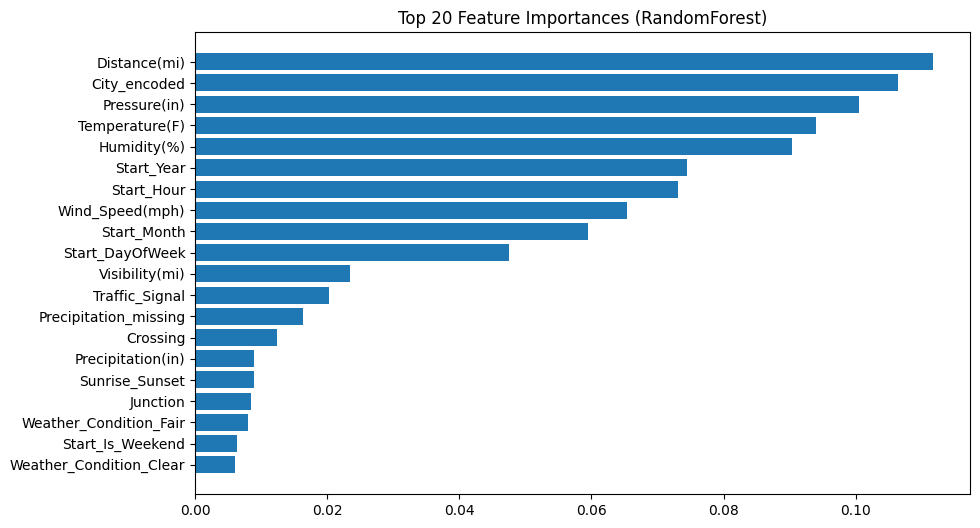

In [367]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
# Split features and target
X = df.drop(columns=['Severity']) # Dataset
y = df['Severity'] # what we want to predict


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=132,
    stratify=y
)
# Train the model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=132,
    n_jobs=-1
)

model.fit(X_train, y_train)
# Use the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feature_importance.head(20))

# Plot top features
top = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 20 Feature Importances (RandomForest)")
plt.show()


# The model has 81% Accuracy but this is misleading because it scores well on the most frequenct severity class (2) but performs very poorly for Severity 4 which is rare, 5% recall, the imbalance is hindering our 
# prediction, for the next iteration of models we will try SMOTE to oversample the rarer classes see if it performs better

Severity
2    312064
3     66422
4     10153
1      3366
Name: count, dtype: int64
Severity
2    312064
3    312064
4    312064
1    312064
Name: count, dtype: int64
Accuracy: 0.7956470276116814

Classification Report:

              precision    recall  f1-score   support

           1       0.39      0.43      0.41       842
           2       0.87      0.89      0.88     78017
           3       0.49      0.47      0.48     16605
           4       0.32      0.17      0.22      2538

    accuracy                           0.80     98002
   macro avg       0.52      0.49      0.50     98002
weighted avg       0.79      0.80      0.79     98002


Confusion Matrix:

[[  359   424    55     4]
 [  382 69441  7570   624]
 [  166  8395  7749   295]
 [    6  1744   362   426]]

Top 20 Important Features:

                            feature  importance
0                      Distance(mi)    0.183011
22                       Start_Year    0.127869
26                     City_encoded    0.08

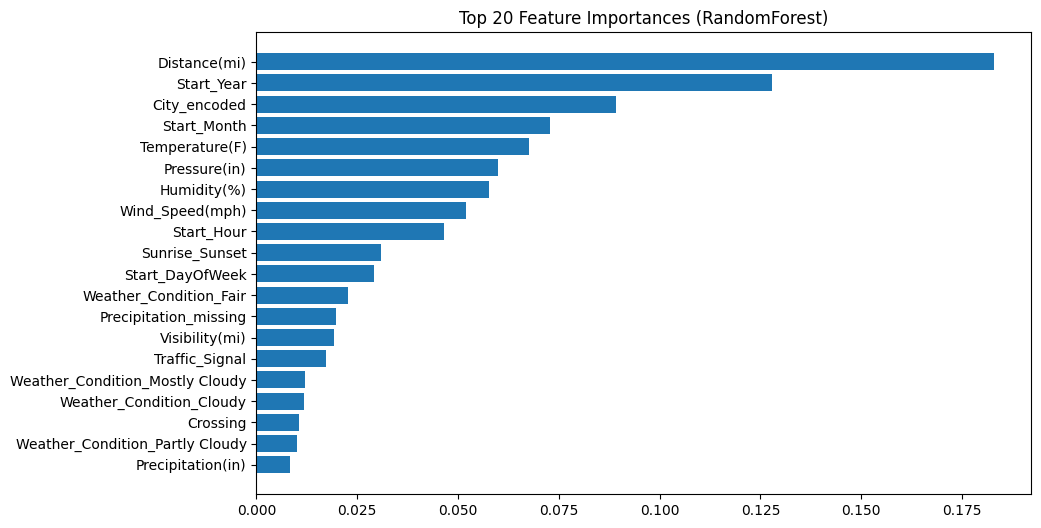

In [368]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=132)
# Do smote on the training data not test
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_resampled.value_counts())

model = RandomForestClassifier(
    n_estimators=100,
    random_state=132,
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
cm = confusion_matrix(y_test, y_pred)
print(cm)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Important Features:\n")
print(feature_importance.head(20))

# Plot top features
top = feature_importance.head(20)

plt.figure(figsize=(10,6))
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.title("Top 20 Feature Importances (RandomForest)")
plt.show()

# So Accuracy dropped slightly and the top variables stayed the same altough in different orders but this improved recall and f1 scores for class 4 and 1 significantly which were the ones that class 3 and 2 dominated mostly 2.
# The model can now detect some severe accidents and very low severity ones but it still struggles, and as we see in the confusion matrix even when wrong we also classify severity 4 more as severity 3 than as severity 2
# although we still classify alot of severity 4 in severity 2, ideally we would like to classify all severity 4 in severity 4 but the next best thing is to predict severity 4 in class severity 3

In [369]:
# We see from the previous models that time plays a big role in predicting the severity but they are mixing randomly across all years
# The model could be learning from past and future mixed together and this could be a problem
# So what we will do now is use past data as train data and test data as future data and apply SMOTE only to the past data